In [1]:
from flonacomldft.utils.io_utils import load_pickle_file
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plot_acceptance_ratio_nsteps(acceptance_ratios, split=10, alpha=0.2, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    for i, acceptance_ratio in enumerate(acceptance_ratios):
        color = next(ax._get_lines.prop_cycler)['color']
        ax.plot(acceptance_ratio, color=color, alpha=alpha)#, label='Model {:d}'.format(i))
        acc_ratio_avg = np.lib.stride_tricks.sliding_window_view(acceptance_ratio, split).mean(axis=1)
        ax.plot(acc_ratio_avg, color=color, label='Model {:d} - average'.format(i))
    ax.set_xlabel('n_steps')
    ax.set_ylabel('acceptance ratio')
    ax.legend()

def plot_participation_ratio(participation_ratios, marker='o-', ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(participation_ratios, marker, label='participation ratio')
    ax.set_xlabel('flow model during training')
    ax.set_ylabel('participation ratio')
    ax.legend()

def plot_acceptance_ratio_models(acceptance_ratios, marker='o-', ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(acceptance_ratios, marker, label='acceptance ratio')
    ax.set_xlabel('flow model during training')
    ax.set_ylabel('acceptance ratio')
    ax.legend()

In [5]:
path = "/home/ana/assisting_sampling/phase_2/dft_ratios/"
ratios_5 = load_pickle_file("is0_mh_ratios_2287931.pkl", path=path)
acceptance_ratios = ratios_5['acc_ratios']
participation_ratios = ratios_5['part_ratios']

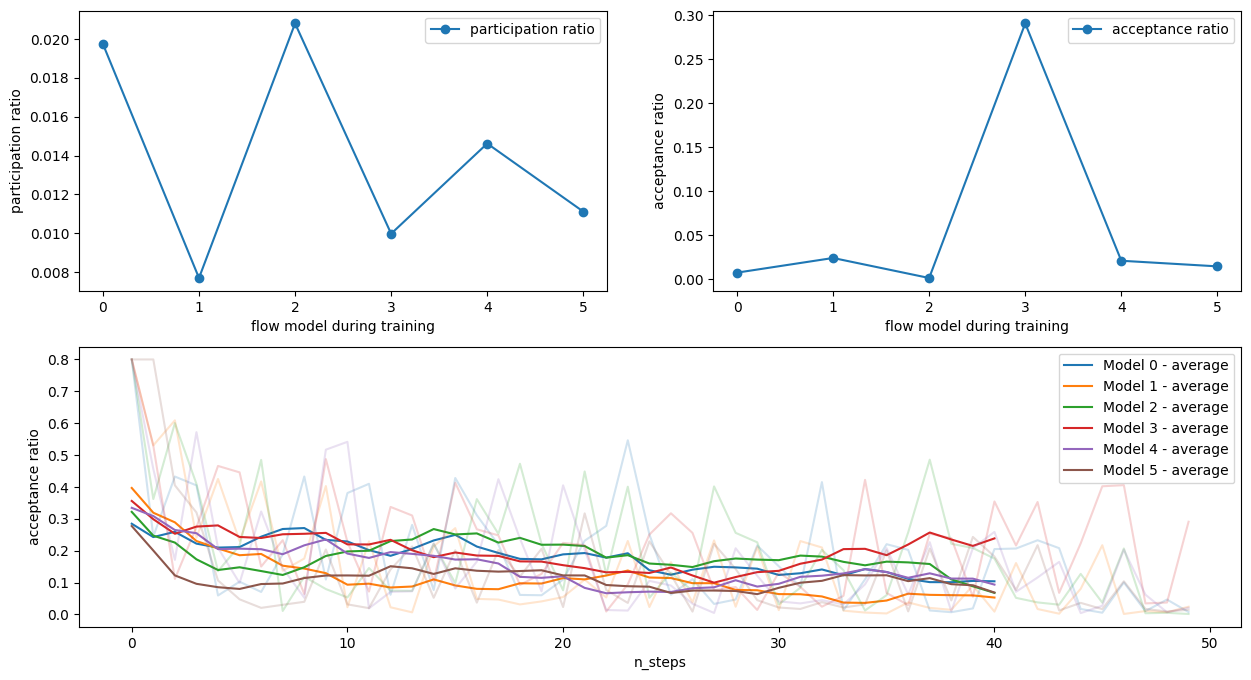

In [6]:
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot(222)
plot_acceptance_ratio_models(acceptance_ratios.detach().numpy()[:, -1], 'o-', ax=ax1)

ax2 = plt.subplot(221)
plot_participation_ratio(participation_ratios.detach().numpy(), ax=ax2)

ax3 = plt.subplot(212)
plot_acceptance_ratio_nsteps(acceptance_ratios.detach().numpy(), ax=ax3)

In [7]:
ratios_10 = load_pickle_file("is0_mh_ratios_2287863.pkl", path=path)
acceptance_ratios = ratios_10['acc_ratios']
participation_ratios = ratios_10['part_ratios']

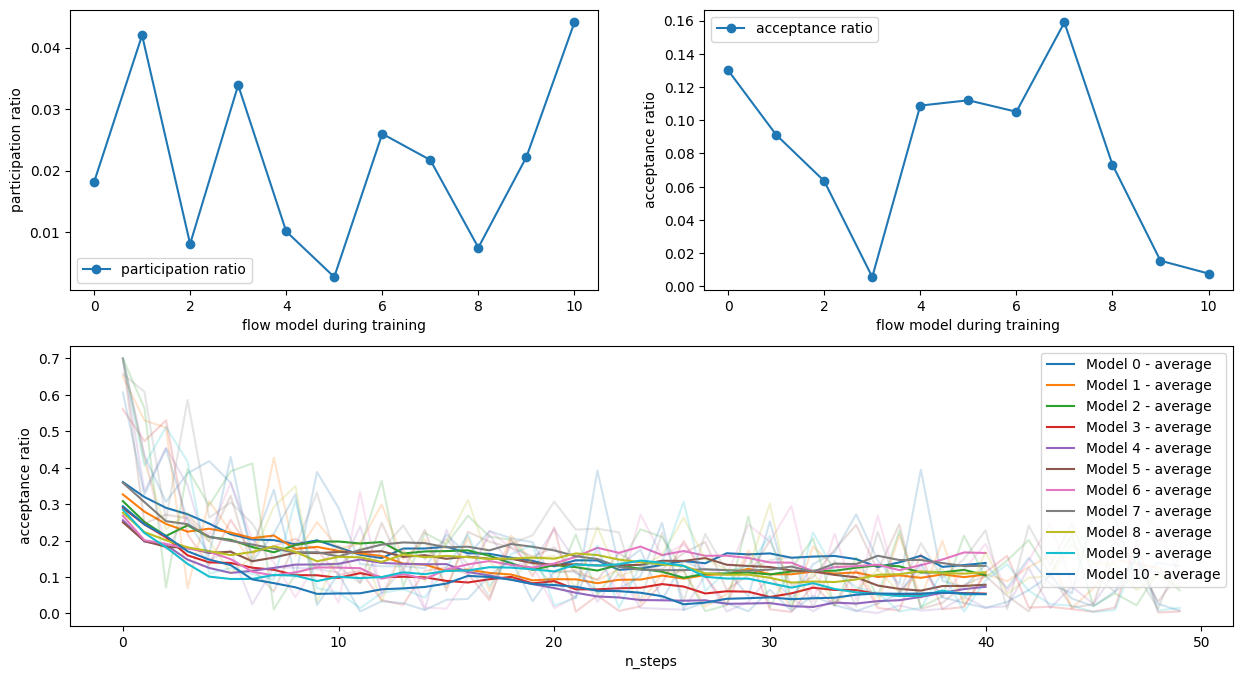

In [8]:
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot(222)
plot_acceptance_ratio_models(acceptance_ratios.detach().numpy()[:, -1], 'o-', ax=ax1)

ax2 = plt.subplot(221)
plot_participation_ratio(participation_ratios.detach().numpy(), ax=ax2)

ax3 = plt.subplot(212)
plot_acceptance_ratio_nsteps(acceptance_ratios.detach().numpy(), ax=ax3)